In [2]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("src folder exists:", (PROJECT_ROOT / "src").exists())

Project root: e:\Telecom churn
src folder exists: True


In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier

from src.preprocessing import load_data, prepare_data

print("All imports successful!")
print("CatBoost experiment ready!")

All imports successful!
CatBoost experiment ready!


In [4]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier

from src.preprocessing import load_data, prepare_data

print("All imports successful!")
print("CatBoost experiment ready!")

All imports successful!
CatBoost experiment ready!


In [5]:
# Load dataset
df = load_data(PROJECT_ROOT / "WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Prepare features and target
X, y, numeric_features, categorical_features = prepare_data(df)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Dataset shape:", X.shape)
print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Dataset shape: (7043, 20)
Training rows: 5634
Test rows: 1409
Numeric features: 4
Categorical features: 16


In [6]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier

# Find project root
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import load_data, prepare_data

# Load dataset
DATA_PATH = PROJECT_ROOT / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = load_data(DATA_PATH)

# Prepare features
X, y, numeric_features, categorical_features = prepare_data(df)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Dataset loaded successfully!")
print("Dataset shape:", X.shape)
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Dataset loaded successfully!
Dataset shape: (7043, 20)
Training rows: 5634
Test rows: 1409
Numeric features: 4
Categorical features: 16


In [7]:
# Train CatBoost model
cat_model = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=200,
    allow_writing_files=False
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)

# Evaluate on the held-out test set
y_prob_cat = cat_model.predict_proba(X_test)[:, 1]

cat_test_auc = roc_auc_score(y_test, y_prob_cat)

print(f"CatBoost Test ROC AUC: {cat_test_auc:.4f}")

0:	total: 344ms	remaining: 5m 43s
200:	total: 12.8s	remaining: 50.9s
400:	total: 24s	remaining: 35.9s
600:	total: 35.6s	remaining: 23.7s
800:	total: 47.4s	remaining: 11.8s
999:	total: 59.1s	remaining: 0us
CatBoost Test ROC AUC: 0.8417


In [9]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier
import numpy as np

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cat_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train), start=1
):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    fold_model = CatBoostClassifier(
        iterations=1000,
        depth=6,
        learning_rate=0.03,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=False,
        allow_writing_files=False
    )

    fold_model.fit(
        X_fold_train,
        y_fold_train,
        cat_features=categorical_features
    )

    fold_probs = fold_model.predict_proba(X_fold_val)[:, 1]
    fold_auc = roc_auc_score(y_fold_val, fold_probs)

    cat_cv_scores.append(fold_auc)
    print(f"Fold {fold}: ROC AUC = {fold_auc:.4f}")

print(f"\nMean CV AUC: {np.mean(cat_cv_scores):.4f}")
print(f"Std CV AUC: {np.std(cat_cv_scores):.4f}")

Fold 1: ROC AUC = 0.8351
Fold 2: ROC AUC = 0.8302
Fold 3: ROC AUC = 0.8437
Fold 4: ROC AUC = 0.8557
Fold 5: ROC AUC = 0.8540

Mean CV AUC: 0.8437
Std CV AUC: 0.0101


In [10]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lgb_cv_scores = []

for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train), start=1
):
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # Identify categorical columns by name
    cat_cols = [
        col for col in categorical_features
        if col in X_fold_train.columns
    ]

    # Copy data to avoid changing the original dataset
    X_fold_train = X_fold_train.copy()
    X_fold_val = X_fold_val.copy()

    for col in cat_cols:
        X_fold_train[col] = X_fold_train[col].astype("category")
        X_fold_val[col] = pd.Categorical(
            X_fold_val[col],
            categories=X_fold_train[col].cat.categories
        )

    lgb_model = LGBMClassifier(
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        random_state=42,
        verbosity=-1
    )

    lgb_model.fit(
        X_fold_train,
        y_fold_train,
        categorical_feature=cat_cols
    )

    probabilities = lgb_model.predict_proba(X_fold_val)[:, 1]
    auc = roc_auc_score(y_fold_val, probabilities)

    lgb_cv_scores.append(auc)
    print(f"Fold {fold}: ROC AUC = {auc:.4f}")

print(f"\nMean CV AUC: {np.mean(lgb_cv_scores):.4f}")
print(f"Std CV AUC: {np.std(lgb_cv_scores):.4f}")

Fold 1: ROC AUC = 0.8247
Fold 2: ROC AUC = 0.8142
Fold 3: ROC AUC = 0.8288
Fold 4: ROC AUC = 0.8383
Fold 5: ROC AUC = 0.8388

Mean CV AUC: 0.8289
Std CV AUC: 0.0092


In [12]:
from src.preprocessing import create_preprocessor

print("create_preprocessor imported successfully!")

create_preprocessor imported successfully!


In [13]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline

gb_pipeline = Pipeline([
    ("preprocessor", create_preprocessor(
        numeric_features, categorical_features
    )),
    ("model", GradientBoostingClassifier(random_state=42))
])

param_dist = {
    "model__n_estimators": [150, 250, 350, 500],
    "model__learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08],
    "model__max_depth": [1, 2, 3],
    "model__min_samples_split": [5, 10, 20, 30],
    "model__min_samples_leaf": [2, 4, 6, 10],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__max_features": [None, "sqrt", "log2"]
}

print("Tuning setup ready!")

Tuning setup ready!


In [14]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True
)

search.fit(X_train, y_train)

print("Best CV AUC:", round(search.best_score_, 4))
print("Best parameters:")
print(search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV AUC: 0.8509
Best parameters:
{'model__subsample': 0.9, 'model__n_estimators': 350, 'model__min_samples_split': 30, 'model__min_samples_leaf': 2, 'model__max_features': None, 'model__max_depth': 1, 'model__learning_rate': 0.08}


In [15]:

from sklearn.metrics import roc_auc_score

best_gb_pipeline = search.best_estimator_

y_test_prob = best_gb_pipeline.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_test_prob)

print(f"Best CV AUC: {search.best_score_:.4f}")
print(f"Best Test AUC: {test_auc:.4f}")


Best CV AUC: 0.8509
Best Test AUC: 0.8483


              precision    recall  f1-score   support

    No Churn       0.84      0.90      0.87      1035
       Churn       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



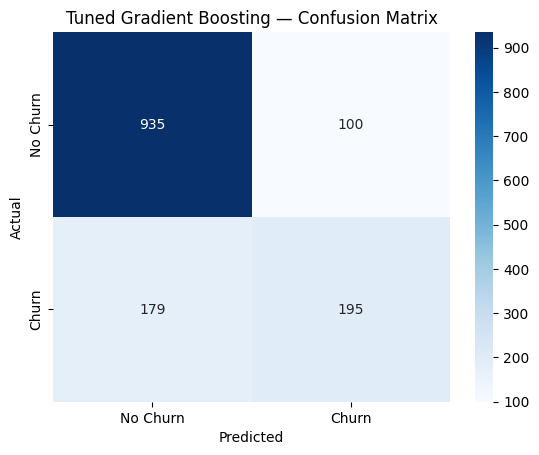

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_test_pred = best_gb_pipeline.predict(X_test)

print(classification_report(
    y_test,
    y_test_pred,
    target_names=["No Churn", "Churn"]
))

cm = confusion_matrix(y_test, y_test_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned Gradient Boosting — Confusion Matrix")
plt.show()

In [17]:
from sklearn.metrics import classification_report, roc_auc_score

# Predicted churn probabilities
y_test_prob = best_gb_pipeline.predict_proba(X_test)[:, 1]

# Lower the classification threshold
threshold = 0.35
y_test_pred_new = (y_test_prob >= threshold).astype(int)

print("ROC-AUC:", round(roc_auc_score(y_test, y_test_prob), 4))
print(f"\nClassification Report (Threshold = {threshold}):\n")

print(classification_report(
    y_test,
    y_test_pred_new,
    target_names=["No Churn", "Churn"]
))

ROC-AUC: 0.8483

Classification Report (Threshold = 0.35):

              precision    recall  f1-score   support

    No Churn       0.89      0.80      0.84      1035
       Churn       0.56      0.72      0.63       374

    accuracy                           0.78      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.78      0.78      1409

